<a href="https://colab.research.google.com/github/dj202410320-png/dlfkd/blob/main/%EC%9D%B4%EB%9E%91_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%9D%98_%ED%9D%A9%EC%96%B4%EC%A7%90_%EC%B8%A1%EC%A0%95_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ⅱ-1-2 데이터의 흩어짐 측정
### [익힘 활동]데이터의 흩어짐 측정 실습하기


### [실습1] 인구 총계의 최대, 최소의 차와 상위 25%, 하위 25%에 해당하는 값의 차이 구하기


1. 제주특별자치도 주민등록인구 통계 현황 공공 데이터 CSV 파일을 업로드한다.


In [1]:
from google.colab import files
uploaded = files.upload()
csv_file = '2025연령별인구현황_연간.csv'

Saving 2025연령별인구현황_연간.csv to 2025연령별인구현황_연간.csv



2. 업로드한 파일을 판다스를 사용하여 데이터 프레임(df)에 저장하고 출력한다.



In [2]:
import pandas as pd

df = pd.read_csv(csv_file, encoding ='cp949')
df

,행정구역,2025년_계_총인구수,2025년_계_연령구간인구수,2025년_계_0~4세,2025년_계_5~9세,2025년_계_10~14세,2025년_계_15~19세,2025년_계_20~24세,2025년_계_25~29세,2025년_계_30~34세,...,2025년_여_55~59세,2025년_여_60~64세,2025년_여_65~69세,2025년_여_70~74세,2025년_여_75~79세,2025년_여_80~84세,2025년_여_85~89세,2025년_여_90~94세,2025년_여_95~99세,2025년_여_100세 이상
0,제주특별자치도 제주시 (5011000000),"485,182","485,182","13,466","19,904","26,678","25,761","23,305","27,692","31,846",...,"20,659","18,300","15,933","10,926","8,509","6,574","4,922","2,439",677,131
1,제주특별자치도 제주시 한림읍(5011025000),"20,123","20,123",351,628,887,840,721,761,869,...,863,873,877,603,519,452,362,181,44,7
2,제주특별자치도 제주시 애월읍(5011025300),"38,310","38,310","1,009","1,610","2,108","1,756","1,299","1,631","2,091",...,"1,683","1,549","1,242",891,690,581,510,279,84,14
3,제주특별자치도 제주시 구좌읍(5011025600),"14,903","14,903",192,393,592,543,464,487,617,...,663,679,639,513,434,359,382,201,45,6
4,제주특별자치도 제주시 조천읍(5011025900),"25,860","25,860",628,"1,011","1,281","1,052",894,"1,156","1,438",...,"1,148","1,073",962,646,533,457,347,176,48,14
5,제주특별자치도 제주시 한경면(5011031000),"9,437","9,437",144,305,351,314,243,274,348,...,396,418,457,310,252,241,238,131,18,8
6,제주특별자치도 제주시 추자면(5011032000),"1,532","1,532",12,27,36,42,33,51,39,...,51,72,85,64,67,56,50,14,6,2
7,제주특별자치도 제주시 우도면(5011033000),"1,491","1,491",20,28,37,39,50,58,85,...,70,82,59,47,47,38,42,20,4,1
8,제주특별자치도 제주시 일도1동(5011051000),"2,072","2,072",18,44,54,46,44,89,90,...,93,100,109,111,76,52,36,17,8,1
9,제주특별자치도 제주시 일도2동(5011052000),"30,917","30,917",777,"1,177","1,642","1,721","1,528","1,763","1,923",...,"1,296","1,361","1,237",906,673,519,322,149,30,5


3. 제주특별자치도 주민등록인구 통계 현황 공공 데이터에서 인구 총계의 최대, 최소의 차와 상위 25%, 하위 25%에 해당하는 값의 차이를 구한다.

In [4]:
df['2025년_계_총인구수'] = df['2025년_계_총인구수'].str.replace(',', '').astype(int)

# 인구 총계의 최대, 최소의 차
max_min_diff = df['2025년_계_총인구수'].max() - df['2025년_계_총인구수'].min()
print(f'인구 총계의 최대, 최소의 차: {max_min_diff}')

# 인구 총계의 상위 25%, 하위 25%에 해당하는 값의 차이 (사분위수 범위)
q75 = df['2025년_계_총인구수'].quantile(0.75)
q25 = df['2025년_계_총인구수'].quantile(0.25)
iqr = q75 - q25
print(f'인구 총계의 상위 25%, 하위 25%에 해당하는 값의 차이 (IQR): {iqr}')

# 분산 계산
print(f'인구 총계의 분산: {df["2025년_계_총인구수"].var()}')

인구 총계의 최대, 최소의 차: 483691
인구 총계의 상위 25%, 하위 25%에 해당하는 값의 차이 (IQR): 17550.0
인구 총계의 분산: 5590781394.4919195


### [실습2] 날짜별 평균 기온을 막대그래프로 표현하기


1. 2025년 제주특별자치도 평균기온의 데이터세트 CSV 파일을 업로드한다.


In [6]:
from google.colab import files
uploaded = files.upload()
csv_file = '2025제주평균기온.csv'

Saving 2025제주평균기온.csv to 2025제주평균기온.csv


2. 업로드한 파일을 판다스를 사용하여 데이터 프레임(df)에 저장하고 출력한다.


In [9]:
import pandas as pd

df=pd.read_csv('data.csv', thousands=',')


FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(csv_file, encoding ='cp949')
print(df)

             일자  평균기온
0    2025-01-01   7.6
1    2025-01-02   8.5
2    2025-01-03   6.0
3    2025-01-04   6.1
4    2025-01-05   8.1
..          ...   ...
360  2025-12-27   4.0
361  2025-12-28   8.3
362  2025-12-29  12.4
363  2025-12-30   8.8
364  2025-12-31   5.9

[365 rows x 2 columns]


3. 날짜별 평균 기온 막대그래프로 표현한다.



AttributeError: 'Series' object has no attribute 'lower'

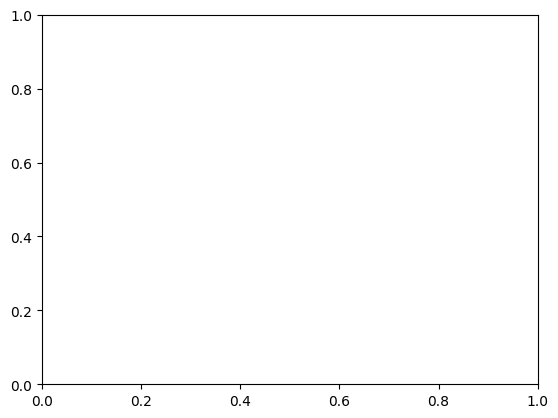

In [12]:
#날짜별 평균 기온 막대그래프로 그리기
plt.grid(['일자'],df['평균기온'])